In [1]:
import os
import uproot
import awkward
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader

In [2]:
path = "/home/tuhin/Python codes and all/" 
file = uproot.open(os.path.join(path,"jet_data.root"))

In [3]:
MAX_PARTICLES = 128
MAX_SAMPLE_PER_CLASS = 8000

In [4]:
class JetDataSet(Dataset):
    def __init__(self,
                 X_tensor: torch.Tensor,
                 P4_tensor:torch.Tensor,
                 mask_tensor:torch.Tensor,
                 label_tensor:torch.Tensor,
                 slice_lim : slice = slice(None)):
        
        self.x = X_tensor[slice_lim]
        self.p4 = P4_tensor[slice_lim]
        self.mask = mask_tensor[slice_lim]
        self.label = label_tensor[slice_lim]

    def __getitem__(self, idx):
        return {"features": self.x[idx],
                "4-momentum" : self.p4[idx],
                "Mask"  : self.mask[idx],
                "Jet Label" : self.label[idx]} 
        
    def __len__(self):
        return len(self.label)

    def __repr__(self):
        return (f"X : {self.x.shape}, P4 : {self.p4.shape}, Mask : {self.mask.shape}, Label : {self.label.shape}")

def prepare_jet_data(path,
                     max_particles,
                     max_sample_per_class,
                     seed = 0):
    path = "/home/tuhin/Python codes and all/" 
    file = uproot.open(os.path.join(path,"jet_data.root"))
    tree = file["tree"]
    branches = tree.keys()
    data = tree.arrays(library="ak")
    required_branch_name = branches[:6]
    required_branch_data = data[required_branch_name]

    is_top = awkward.to_numpy(data["label_Tbl"]|data["label_Tbqq"]).astype(bool)
    is_qcd = awkward.to_numpy(data["label_QCD"]).astype(bool)
    jet_index = np.concatenate((np.where(is_qcd)[0][:max_sample_per_class],
                                np.where(is_top)[0][:max_sample_per_class]))

    jet_labels = np.concatenate((np.zeros(max_sample_per_class),np.ones(max_sample_per_class)))
    top_qcd_branch = required_branch_data[jet_index]

    px,py,pz,energy,deta,dphi = [top_qcd_branch[feat] for feat in required_branch_name]

    pt = np.sqrt(px**2+py**2)
    dR = np.sqrt(deta**2+dphi**2)
    pt_jet = np.sqrt((np.sum(px,axis = 1))**2 + (np.sum(py,axis = 1))**2)
    energy_jet = np.sum(energy,axis = 1)
    log_energy = np.log(energy)
    log_pt = np.log(pt)
    log_pt_rel = np.log(pt/pt_jet)
    log_energy_rel = np.log(energy/energy_jet)

    feature_list = [deta,dphi,log_pt,log_energy,log_pt_rel,log_energy_rel,dR]
    FEATURE_NAMES = ["deta","dphi","log_pt","log_energy","log_pt_rel","log_energy_rel","dR"]

    def pad_feat(feat_name):
        return awkward.to_numpy(awkward.fill_none(awkward.pad_none(feat_name,max_particles,axis = 1,clip = True),0.0,axis = 1))

    features = np.stack([pad_feat(feat) for feat in feature_list],axis = -1).astype(np.float32)
    P4 = np.stack([pad_feat(feat) for feat in [px,py,pz,energy]],axis = -1).astype(np.float32)
    nparts = awkward.to_numpy(awkward.num(pt,axis=1))
    mask = (np.arange(max_particles)[None,:]< nparts[:,None])

    features_mean,features_std = features[mask].mean(axis=0),features[mask].std(axis = 0)

    X = (features - features_mean)/features_std

    X_tensor , P4_tensor , mask_tensor , label_tensor = map(torch.from_numpy,[X,P4,mask,jet_labels])

    gen = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(label_tensor),generator=gen)
    X_tensor , P4_tensor , mask_tensor , label_tensor = X_tensor[perm] , P4_tensor[perm] , mask_tensor[perm] , label_tensor[perm]

    return X_tensor , P4_tensor , mask_tensor , label_tensor

def create_loader(jet_dataset: JetDataSet,train_frac,test_frac,batch_size = 64):

    num_jets = len(jet_dataset)
    n_train = int(train_frac*num_jets)
    n_test = int(test_frac*num_jets)

    split = {
        "train" : slice(0,n_train),
        "test" : slice(n_train,n_test+n_train),
        "val" : slice(n_train+n_test,num_jets)
    }

    loaders = { key : DataLoader(JetDataSet(
        jet_dataset.x,
        jet_dataset.p4,
        jet_dataset.mask,
        jet_dataset.label,
        value
    ),batch_size=batch_size,shuffle = key=="train") for key,value in split.items()}

    print({key: len(JetDataSet(
            jet_dataset.x,
            jet_dataset.p4,
            jet_dataset.mask,
            jet_dataset.label,
            s)) for key, s in split.items()})
    
    return loaders





In [5]:
X,P4,mask,label = prepare_jet_data(path = "/home/tuhin/Python codes and all/",
                                   max_particles = MAX_PARTICLES,
                                   max_sample_per_class = MAX_SAMPLE_PER_CLASS,
                                   seed = 0)

jet_dataset = JetDataSet(X_tensor= X,
                            P4_tensor = P4,
                            mask_tensor = mask,
                            label_tensor = label)

print(jet_dataset[0]["features"].shape)

loader = create_loader(jet_dataset=jet_dataset,
                    train_frac = 0.7,
                    test_frac = 0.15)

torch.Size([128, 7])
{'train': 11200, 'test': 2400, 'val': 2400}


In [6]:
# test_X = jet_dataset.x[:40]
# test_mask = jet_dataset.mask[:40]
# test_y = jet_dataset.label[:40]

In [7]:
import torch.nn as nn
from torch.nn import functional as F
import math

In [8]:
def scaled_attention(
                    Q: torch.Tensor,
                    K : torch.Tensor,
                    V : torch.Tensor,
                    attn_bias = None,
                    mask = None):
    dim_k = K.shape[-1]
    score_matrix = torch.matmul(Q,K.transpose(dim0 = -2 , dim1 = -1))/math.sqrt(dim_k)

    if attn_bias is not None:
        score_matrix = score_matrix + attn_bias
        
    if mask is not None:
        score_matrix = score_matrix.masked_fill(~mask[:,None,None,:],float("-inf"))
        
    attention_matrix = F.softmax(score_matrix, dim = -1)
    attention_matrix = torch.nan_to_num(attention_matrix)
    out = attention_matrix @ V

    return out, attention_matrix

def pairwise_features(P4, eps=1e-8):
    
    px, py, pz, E = P4[..., 0], P4[..., 1], P4[..., 2], P4[..., 3]
    pt  = torch.sqrt(px**2 + py**2).clamp(min=1e-6)
    phi = torch.atan2(py, px)
    y   = 0.5 * torch.log(((E + pz).clamp(min=eps)) / ((E - pz).clamp(min=eps)))     # rapidity

    dy   = y[:, :, None] - y[:, None, :]
    dphi = phi[:, :, None] - phi[:, None, :]
    dphi = torch.atan2(torch.sin(dphi), torch.cos(dphi))                              # wrap to (-pi, pi], MPS-safe
    delta = torch.sqrt(dy**2 + dphi**2).clamp(min=1e-6)

    pt_min = torch.minimum(pt[:, :, None], pt[:, None, :])
    kt = (pt_min * delta).clamp(min=1e-6)
    z  = (pt_min / (pt[:, :, None] + pt[:, None, :] + eps)).clamp(min=1e-6, max=1.0)
    sum_E, sum_px = E[:, :, None] + E[:, None, :], px[:, :, None] + px[:, None, :]
    sum_py, sum_pz = py[:, :, None] + py[:, None, :], pz[:, :, None] + pz[:, None, :]
    m2 = (sum_E**2 - sum_px**2 - sum_py**2 - sum_pz**2).clamp(min=1e-6)

    U = torch.stack([torch.log(delta), torch.log(kt), torch.log(z), torch.log(m2)], dim=-1)

    return U

In [9]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self,emb_dim, head, ratio = 2):
        super().__init__()
        assert emb_dim%head == 0
        self.dim_head , self.dim_k = head, emb_dim//head
        self.QKV = nn.Linear(emb_dim,3*emb_dim) #(D,3D)
        self.ln1,self.ln2 = nn.LayerNorm(emb_dim),nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim,ratio*emb_dim),
            nn.GELU(),
            nn.LayerNorm(ratio*emb_dim),
            nn.Linear(ratio*emb_dim,emb_dim)
        )
    
    def forward(self,x: torch.Tensor,mask = None,attn_bias = None):
        B,N,D = x.shape
        normed_x = self.ln1(x)

        QKV = self.QKV(normed_x) #(B,N,3D)
        QKV = QKV.reshape(B,N,3,self.dim_head,self.dim_k).permute(2,0,3,1,4) #(3,B,H.N.dk)
        Q ,K ,V = QKV[0],QKV[1],QKV[2] # Q,K,V : (B,H,N,dk)

        out ,attention = scaled_attention(Q=Q, K=K, V=V, mask=mask, attn_bias=attn_bias) # out : (B,H,N,dk) 
        out = out.permute(0,2,1,3).reshape(B,N,D) # (B,N,D)
  
        out = self.ln2(out)
        out = out + x

        new_out = self.mlp(out)

        return out + new_out , attention

class ClassAttentionBlock(nn.Module):
    def __init__(self, emb_dim, head, ratio = 2):
        super().__init__()
        assert emb_dim % head == 0
        self.dim_head, self.dim_k = head, emb_dim//head
        self.x_class = nn.Parameter(torch.randn([1,1,emb_dim]))

        self.ln1,self.ln2 = nn.LayerNorm(emb_dim),nn.LayerNorm(emb_dim)
        self.Q,self.KV = nn.Linear(emb_dim,emb_dim),nn.Linear(emb_dim,2*emb_dim)
        self.mlp = nn.Sequential(
                    nn.LayerNorm(emb_dim),
                    nn.Linear(emb_dim,ratio*emb_dim),
                    nn.GELU(),
                    nn.LayerNorm(ratio*emb_dim),
                    nn.Linear(ratio*emb_dim,emb_dim)
                )

    def forward(self,x,mask,modified_x_class = None):
        
        B,N,D = x.shape
        x_class = self.x_class.expand([B,-1,-1])
        if modified_x_class is not None:
            x_class = modified_x_class
        x_cat = torch.concat((x_class,x),dim = -2)
        normed_x_cat = self.ln1(x_cat)

        Q = self.Q(x_class)
        Q = Q.reshape(B,1,self.dim_head,self.dim_k).permute(0,2,1,3) #(B,H,1,dk)
        KV = self.KV(normed_x_cat)  #(B,N+1,2D)
        KV = KV.reshape(B,N+1,2,self.dim_head,self.dim_k).permute(2,0,3,1,4) #(2,B,H,N+1,dk)
        K ,V = KV[0],KV[1]      # K,V : (B,H,N+1,dk)


        class_mask = torch.ones(B, 1,dtype=mask.dtype,)
        class_attn_mask = torch.cat([class_mask, mask],dim=1)

        out ,attention = scaled_attention(Q=Q, K=K, V=V, mask=class_attn_mask) # out : (B,H,N,dk)   
        out = out.permute(0,2,1,3).reshape(B,1,D) # (B,N,D)


        out = self.ln2(out)
        out = out + x_class

        new_out = self.mlp(out)
        return out + new_out

class ParticleTransformer(nn.Module):
    def __init__(self,in_feat,out_feat,emb_dim,head,depth = 3,use_bias = True):
        super().__init__()

        self.use_bias = use_bias

        self.input_projection = nn.Linear(in_feat,emb_dim)
        self.particle_attn_section = nn.ModuleList([MultiHeadAttentionBlock(emb_dim,head) for _ in range(depth)])
        self.class_attn_1 = ClassAttentionBlock(emb_dim,head)
        self.class_attn_2 = ClassAttentionBlock(emb_dim,head)
        self.MLP_head = nn.Linear(emb_dim,out_feat)

        if self.use_bias:
            self.interaction_mlp = nn.Sequential(
                    nn.Linear(4, 16), 
                    nn.GELU(), 
                    nn.Linear(16, head)
                )

    def forward(self,x,mask,P4 = None):

        attn_bias = None
        self.attention = None
        self.attn_map = []

        if P4 is not None and self.use_bias:
            U = pairwise_features(P4=P4)
            attn_bias = self.interaction_mlp(U)
            attn_bias = attn_bias.permute(0,3,1,2)

        emb_x = self.input_projection(x)

        for block in self.particle_attn_section:
            emb_x , self.attention = block(emb_x,mask,attn_bias)
            self.attn_map.append(self.attention.detach())

        x_class_mod = self.class_attn_1(emb_x,mask)

        output = self.class_attn_2(emb_x, mask, modified_x_class = x_class_mod)
        output = output.squeeze(dim = 1)

        logits = self.MLP_head(output)

        return logits


In [10]:
from sklearn.metrics import roc_curve,roc_auc_score

In [11]:
@torch.no_grad()
def evaluate(model:nn.Module , loader : DataLoader):
    model.eval()
    all_labels,all_scores = [],[]
    loss_sum = 0.0
    num_sample = 0.0
    for batch in loader:
        x = batch["features"]
        p4 = batch["4-momentum"]
        mask = batch["Mask"]
        y = batch["Jet Label"]

        logits = model(x,mask,p4)

        num_sample += y.size(0)

        loss_sum += F.cross_entropy(logits,y.long(),reduction="sum").item()
        probs = F.softmax(logits,dim = -1)[:,1]

        all_labels.append(y)
        all_scores.append(probs)

    avg_loss = loss_sum/num_sample
    Y = torch.cat(all_labels)
    P_top = torch.cat(all_scores)
    prediction = (P_top>0.5).long()
    accuracy = (prediction == Y).numpy().astype(int).mean()

    return {"loss" : avg_loss, 
            "accuracy" : accuracy , 
            "Y" : Y , 
            "probability_top" : P_top,
            "AUC Score" : roc_auc_score(Y.numpy(),P_top.numpy())}

def train(model:nn.Module, loader:DataLoader, epochs = 10, lr=1e-3, weight_decay = 1e-2):
    optimizer = torch.optim.AdamW(model.parameters(),lr = lr,weight_decay=weight_decay)
    hist = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_AUC Score": []}  
    for epoch in range(epochs):
        loss_sum, n_batch = 0.0,0.0
        model.train()
        for batch in loader["train"]:
            x = batch["features"]
            p4 = batch["4-momentum"]
            mask = batch["Mask"]
            y = batch["Jet Label"]

            logits = model(x,mask,p4)
            loss = F.cross_entropy(logits,y.long())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            n_batch += 1

        epoch_loss = loss_sum/max(1,n_batch)
        hist["train_loss"].append(epoch_loss)

        validation = evaluate(model,loader["val"])

        for keys in ("loss","accuracy","AUC Score"):
            hist["val_"+keys].append(validation[keys])

        print(f"epoch {epoch+1:2d}: train loss {epoch_loss:.3f} | val loss {validation['loss']:.3f} | "
                      f"acc {validation['accuracy']:.3f} | AUC {validation['AUC Score']:.4f}")
    model.history = hist
    return model
        
def background_rejection(Y, P_top, signal_eff=0.5):
    FPR, TPR, theshold = roc_curve(Y,P_top)
    eps_b = np.interp(signal_eff, TPR, FPR)
    N_background = max(int((Y == 0).sum()),1)
    eps_b = max(eps_b, 1.0 /N_background)  
    return 1.0 / eps_b

In [12]:
ParT = ParticleTransformer(in_feat=7,out_feat=2,emb_dim=64,head=4).to('cpu')


In [13]:
ParT = train(ParT,loader=loader,epochs = 5)

epoch  1: train loss 0.360 | val loss 0.160 | acc 0.939 | AUC 0.9873
epoch  2: train loss 0.134 | val loss 0.125 | acc 0.958 | AUC 0.9904
epoch  3: train loss 0.115 | val loss 0.127 | acc 0.952 | AUC 0.9906
epoch  4: train loss 0.105 | val loss 0.096 | acc 0.965 | AUC 0.9927
epoch  5: train loss 0.100 | val loss 0.098 | acc 0.967 | AUC 0.9926


In [14]:
PlainT = ParticleTransformer(in_feat=7,out_feat=2,emb_dim=64,head=4,use_bias=False).to('cpu')

In [15]:
PlainT = train(PlainT,loader=loader,epochs = 5)

epoch  1: train loss 0.369 | val loss 0.194 | acc 0.921 | AUC 0.9811
epoch  2: train loss 0.181 | val loss 0.150 | acc 0.942 | AUC 0.9861
epoch  3: train loss 0.150 | val loss 0.161 | acc 0.941 | AUC 0.9842
epoch  4: train loss 0.142 | val loss 0.153 | acc 0.941 | AUC 0.9869
epoch  5: train loss 0.138 | val loss 0.138 | acc 0.950 | AUC 0.9892


In [16]:
validation_ParT = evaluate(ParT,loader["test"])

In [17]:
validation_ParT

{'loss': 0.09780782426397006,
 'accuracy': np.float64(0.9641666666666666),
 'Y': tensor([1., 0., 1.,  ..., 0., 0., 1.], dtype=torch.float64),
 'probability_top': tensor([0.9519, 0.0046, 0.9997,  ..., 0.0076, 0.0038, 0.9993]),
 'AUC Score': 0.992895685703245}

In [18]:
validation_PlainT = evaluate(PlainT,loader["test"])

In [19]:
validation_PlainT

{'loss': 0.14869704087575278,
 'accuracy': np.float64(0.9458333333333333),
 'Y': tensor([1., 0., 1.,  ..., 0., 0., 1.], dtype=torch.float64),
 'probability_top': tensor([0.9524, 0.0064, 0.9998,  ..., 0.0093, 0.0097, 0.9996]),
 'AUC Score': 0.9865551790187124}

In [20]:
import matplotlib.pyplot as plt

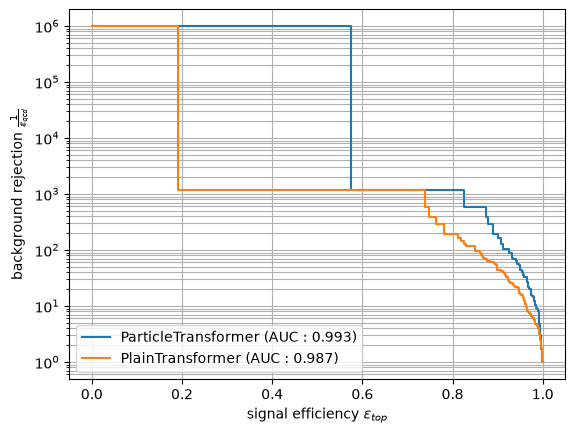

In [21]:
for model,validation in {"ParticleTransformer" : validation_ParT, "PlainTransformer" : validation_PlainT}.items():
    Y = validation["Y"].numpy()
    P_top = validation["probability_top"].numpy()

    FPR,TPR,_ = roc_curve(Y,P_top)
    plt.plot(TPR,1/np.clip(FPR,1e-6,1.0),label = f"{model} (AUC : {validation["AUC Score"]:.3f})")
    plt.yscale("log")
    plt.grid(True,which="both")

plt.xlabel(r"signal efficiency $\epsilon_{top}$")
plt.ylabel(r"background rejection $\frac{1}{\epsilon_{qcd}}$")
plt.legend()
plt.show()

In [22]:
efficiencies = [0.3, 0.5, 0.7]
for model, validation in {"ParticleTransformer": validation_ParT,"PlainTransformer": validation_PlainT}.items():

    Y = validation["Y"].numpy()
    P_top = validation["probability_top"].numpy()

    rejections = [
        background_rejection(Y, P_top, signal_eff=e)
        for e in efficiencies
    ]
    print(f"{model}:")
    for i in range(len(efficiencies)):
        print(f"  efficiency = {efficiencies[i]} → rejection = {rejections[i]:.2f}")


ParticleTransformer:
  efficiency = 0.3 → rejection = 1166.00
  efficiency = 0.5 → rejection = 1166.00
  efficiency = 0.7 → rejection = 1166.00
PlainTransformer:
  efficiency = 0.3 → rejection = 1166.00
  efficiency = 0.5 → rejection = 1166.00
  efficiency = 0.7 → rejection = 1166.00


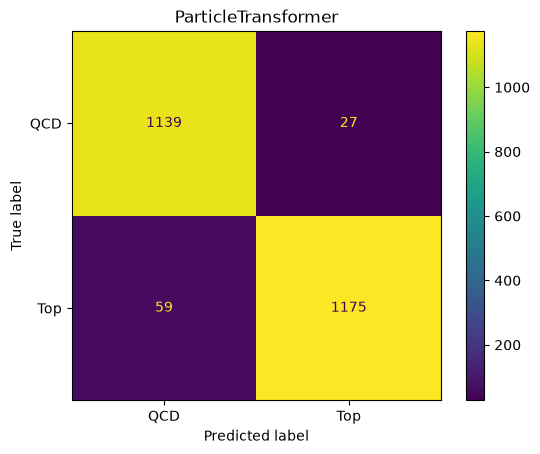

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

P_top = validation_ParT["probability_top"].numpy()
pred = (P_top > 0.5).astype(int)

cm = confusion_matrix(Y, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["QCD", "Top"]
)

disp.plot()
plt.title("ParticleTransformer")
plt.show()

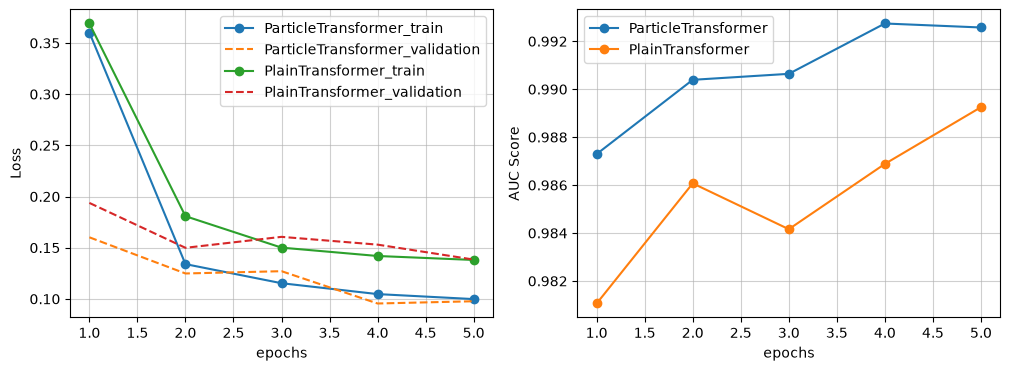

In [24]:
fig,ax = plt.subplots(1,2,figsize = (12,4))
epochs = range(1,6)
for name,model in {"ParticleTransformer": ParT,"PlainTransformer" :PlainT}.items():
    train_loss = model.history["train_loss"]
    val_loss = model.history["val_loss"]
    val_AUC = model.history["val_AUC Score"]
    ax[0].plot(epochs,train_loss,'-o',label = f"{name}_train")
    ax[0].plot(epochs,val_loss,'--',label = f"{name}_validation")
    ax[1].plot(epochs,val_AUC,'-o',label = f"{name}")
ax[0].legend()
ax[1].legend()
ax[0].grid(True,alpha = 0.6)    
ax[1].grid(True,alpha = 0.6) 
ax[0].set_xlabel("epochs")
ax[1].set_xlabel("epochs")
ax[0].set_ylabel("Loss")
ax[1].set_ylabel("AUC Score")
plt.show()

In [25]:
jet_idx = 5003

x_jet = jet_dataset.x[jet_idx].unsqueeze(0)
p4_jet = jet_dataset.p4[jet_idx].unsqueeze(0)
m_jet = jet_dataset.mask[jet_idx].unsqueeze(0)
label_jet = jet_dataset.label[jet_idx]

ParT.eval()

with torch.no_grad():
    logits = ParT(x_jet, m_jet, p4_jet)

A = ParT.attn_map [2][0]  # (4,128,128)
A = A.mean(0)
n = m_jet.sum(1)
A_real = A[:n,:n]


print(label_jet)


tensor(1., dtype=torch.float64)


In [26]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

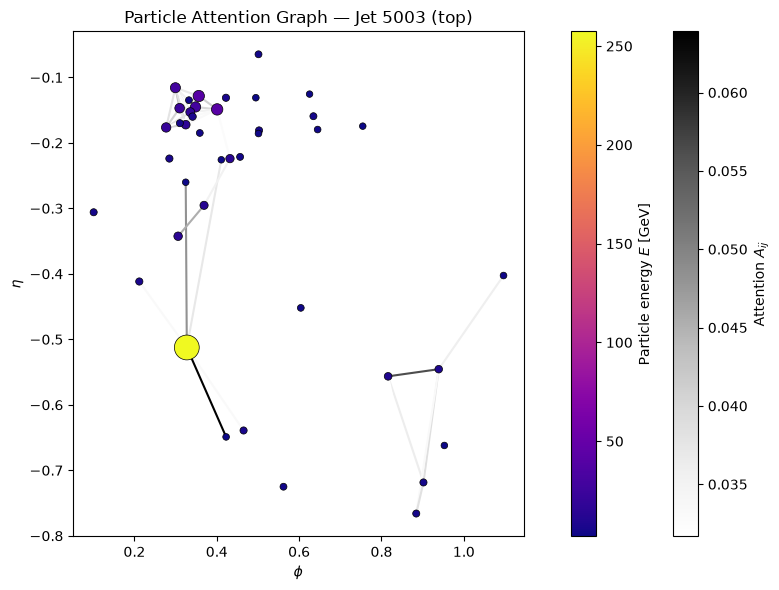

In [27]:
p4 = p4_jet[0]
px, py, pz, E = p4.unbind(-1)
p = torch.sqrt(px**2 + py**2 + pz**2)
eta = 0.5 * torch.log((p + pz).clamp(min=1e-8) /(p - pz).clamp(min=1e-8))
phi = torch.atan2(py, px)

n = int(m_jet.sum().item())

eta = eta[:n].cpu().numpy()
phi = phi[:n].cpu().numpy()
E = E[:n].cpu().numpy()

A = ParT.attn_map[2][0].mean(dim=0)[:n, :n]
A = A.detach().numpy()
A_edge = A.copy()

# np.fill_diagonal(A_edge, 0)
threshold = np.percentile(A_edge[A_edge > 0],90)

fig, ax = plt.subplots(figsize=(8, 6))
segments = []
edge_values = []

for i in range(n):
    for j in range(i + 1, n):
        if A_edge[i, j] < threshold:
            continue
        segments.append([[phi[i], eta[i]],[phi[j], eta[j]]])
        edge_values.append(A_edge[i, j])

edge_values = np.asarray(edge_values)
edge_norm = Normalize(vmin=edge_values.min(),vmax=edge_values.max())
edge_lc = LineCollection(segments,cmap="Greys",norm=edge_norm,linewidths=1.5)
edge_lc.set_array(edge_values)

ax.add_collection(edge_lc)

cbar_attention = fig.colorbar(edge_lc,ax=ax,pad=0.02)
cbar_attention.set_label(r"Attention $A_{ij}$")

particle_norm = Normalize(vmin=E.min(),vmax=E.max())
 
sc = ax.scatter(phi,eta,s= 20+300*E/E.max(),c=E,cmap="plasma",norm=particle_norm,edgecolors="black",linewidths=0.5,zorder=3)

cbar_energy = fig.colorbar(sc,ax=ax,pad=0.08)
cbar_energy.set_label(r"Particle energy $E$ [GeV]")

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\eta$")
ax.set_title(f"Particle Attention Graph — Jet {jet_idx} ({"top" if label_jet == 1 else "QCD"})")

plt.tight_layout()
plt.show()